# 02 — Net-basis / BNOC relative-value signal

**Idea.** BNOC (basis net of carry = net basis) is the market price of the short's **delivery options**. Trade it relative-value: **BUY the basis when BNOC is cheap** vs its trailing history (long optionality), **SELL when rich**. Mean-reversion z-score with hysteresis, per tenor; positions roll automatically with the front contract. Same correct PnL + repo financing as NB1.

Uses `build_basis_panel` (daily CTD basis metrics, cached) + `bnoc_zscore_signal` + `run_ustf_basis_signal_backtest`.

In [1]:
import sys, os
REPO = r"C:\\Users\\chris\\clee\\ARBS"
if REPO not in sys.path:
    sys.path.insert(0, REPO)
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.display.float_format = lambda x: f'{x:,.2f}'
from BT.signals.ustf_basis import (UstfBasisConfig, build_basis_panel, bnoc_zscore_signal,
                                   run_ustf_basis_signal_backtest, plot_pnl)
from MDP.USTFutures.USTFuturesMDP import USTFuturesMDP

In [2]:
START, END = datetime.date(2024, 6, 1), datetime.date(2026, 5, 31)
TENORS = ["TU", "FV", "TY", "US"]
SPECIALNESS_BPS = {"TU": 5.0, "FV": 8.0, "TY": 10.0, "US": 12.0}  # CTD repo specialness
Z_WINDOW, Z_ENTRY, Z_EXIT = 60, 1.0, 0.25
cfg = UstfBasisConfig(tenors=TENORS, start=START, end=END, bond_face=100_000_000.0,
                      specialness_bps=SPECIALNESS_BPS, tx_cost_32nds=0.5, show_progress=True)
mdp = USTFuturesMDP(source='BARCHART_USTF-RL')

Build (and cache) the daily basis panels, then run the signal backtest.

BACKTESTING...:   0%|          | 0/497 [00:00<?, ?step/s]

BACKTESTING...:   4%|▍         | 20/497 [00:01<00:24, 19.77step/s]

BACKTESTING...:   4%|▍         | 22/497 [00:01<00:26, 17.83step/s]

BACKTESTING...:   5%|▍         | 24/497 [00:01<00:29, 16.22step/s]

BACKTESTING...:   5%|▌         | 26/497 [00:01<00:31, 14.89step/s]

...

BACKTESTING...:  98%|█████████▊| 487/497 [02:36<00:04,  2.36step/s]

BACKTESTING...:  98%|█████████▊| 488/497 [02:37<00:04,  2.21step/s]

BACKTESTING...: 100%|█████████▉| 496/497 [02:38<00:00,  4.32step/s]

BACKTESTING...: 100%|██████████| 497/497 [02:38<00:00,  4.18step/s]

BACKTESTING...: 100%|██████████| 497/497 [02:38<00:00,  3.13step/s]

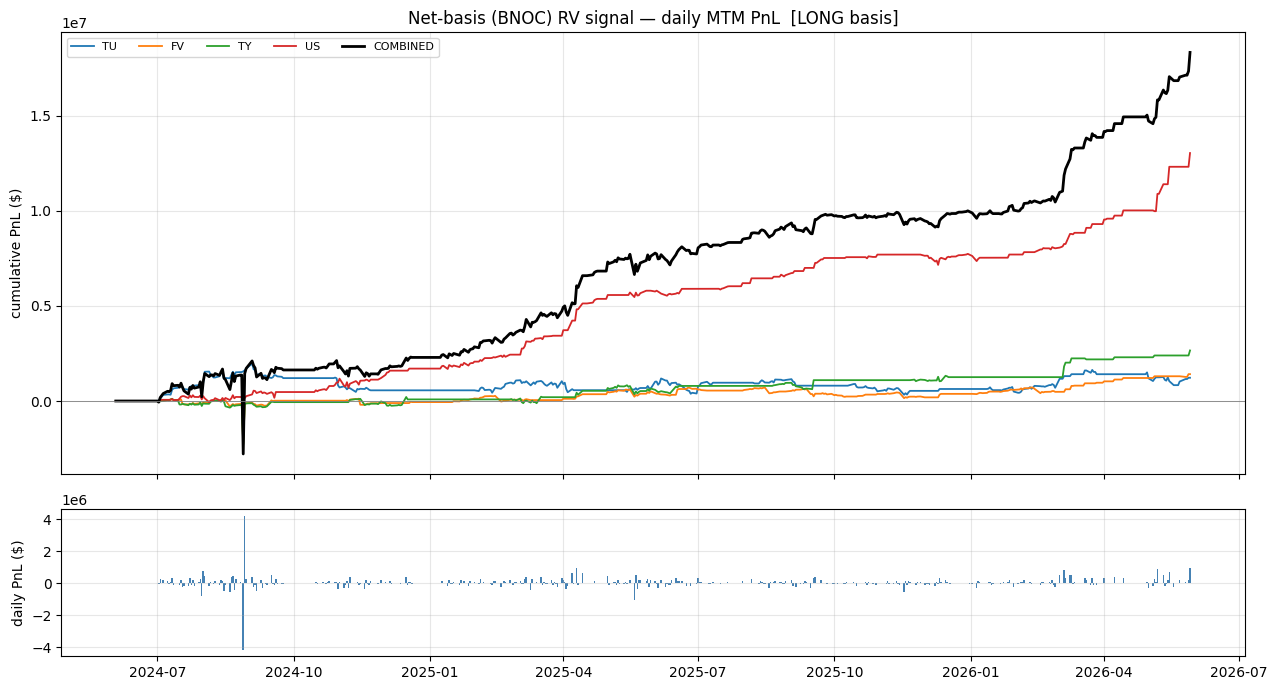

In [3]:
panels = {t: build_basis_panel(t, START, END, roll_days=cfg.roll_days_before_first_notice, mdp=mdp) for t in TENORS}
signal = bnoc_zscore_signal(window=Z_WINDOW, z_entry=Z_ENTRY, z_exit=Z_EXIT)
res = run_ustf_basis_signal_backtest(cfg, signal, mdp=mdp, panels=panels)
fig = plot_pnl(res, title='Net-basis (BNOC) RV signal — daily MTM PnL')

## BNOC z-score and position (example tenor)

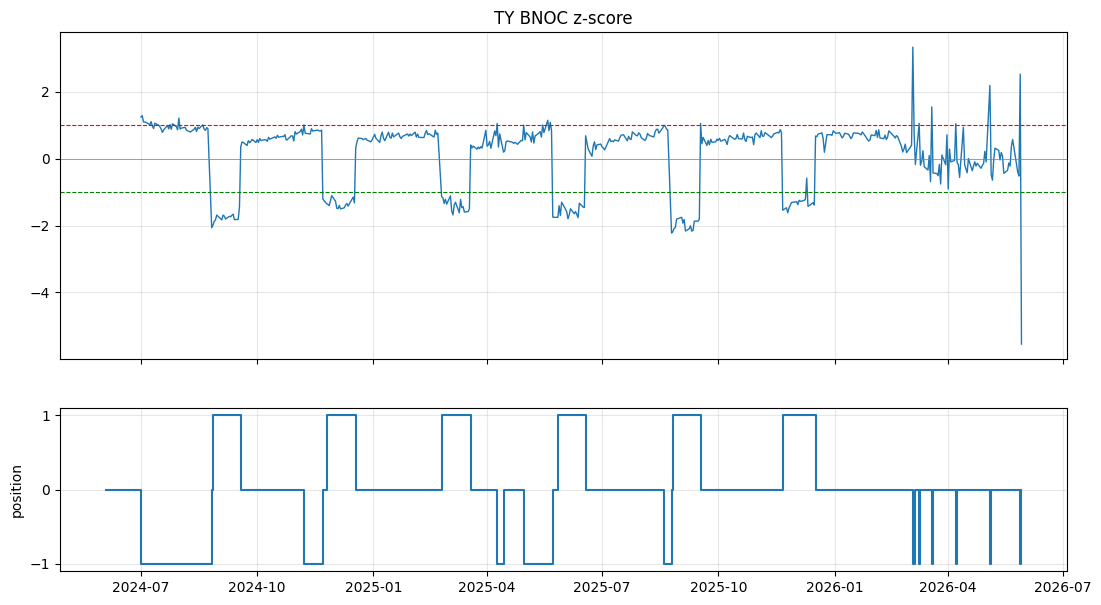

In [4]:
t = 'TY'
panel = panels[t]; s = panel['bnoc'].astype(float)
mu = s.rolling(Z_WINDOW, min_periods=20).mean(); sd = s.rolling(Z_WINDOW, min_periods=20).std()
z = (s - mu) / sd
pos = res.signals_by_tenor[t]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, height_ratios=[2, 1])
a1.plot(z.index, z, lw=1); a1.axhline(Z_ENTRY, color='r', ls='--', lw=0.8); a1.axhline(-Z_ENTRY, color='g', ls='--', lw=0.8)
a1.axhline(0, color='grey', lw=0.5); a1.set_title(f'{t} BNOC z-score'); a1.grid(alpha=0.3)
a2.plot(pos.index, pos, drawstyle='steps-post'); a2.set_ylabel('position'); a2.set_yticks([-1, 0, 1]); a2.grid(alpha=0.3)
plt.show()